# Tidal Harmonic Analysis of Tide Gauge Data

This notebook demonstrates how to:

1. Parse a National Oceanography Centre (NOC/BODC) tide gauge record.
2. Perform harmonic analysis using UTide via `pyfvcom2.tide.analyse_harmonics`.
3. Compare the derived amplitudes and phases against TPXO10 Atlas harmonics at
   the same location.
4. Overlay the reconstructed tidal signal on the observed record.

**Dataset:** Devonport (P002) sea-level record for December 2025, 15-minute
sampling, referenced to Admiralty Chart Datum (ACD).
Sourced from BODC under the Open Government Licence.

**TPXO:** TPXO10 Atlas (30 arc-minute resolution), elevation constituents.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from netCDF4 import date2num

from pyfvcom2.tide import analyse_harmonics, DEFAULT_CONSTIT, MJD_ZERO_POINT
from pyfvcom2.interpolation import InterpolationCoordinates, TPXOInterpolator
from pyfvcom2.tide_reader import TPXOComplexHarmonicsReader, get_tpxo_complex_harmonics_names

# ── Data paths ────────────────────────────────────────────────────────────────
DATA_DIR = os.path.expanduser('~/data/pyfvcom2_doc')
GAUGE_FILE = f'{DATA_DIR}/TideGuage/Devonport/Dec2025/DEV2512.txt'
TPXO_DIR   = f'{DATA_DIR}/TPXO/DATA/Atlas10v2'

# Devonport gauge coordinates
GAUGE_LAT =  50.36839
GAUGE_LON =  -4.18525
N_HEADER  =  12   # fixed-width header lines in the BODC file

/local1/data/scratch/jcl/miniconda/miniconda3/envs/pyfvcom2/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## 1. Load and parse the tide gauge data

The BODC fixed-width format has 12 header lines followed by records with
columns: cycle number, date, time, surface elevation (m ACD), residual (m).
Values flagged `M` (unlikely to be realistic) are replaced with `NaN`;
UTide handles gaps and missing data internally.

In [2]:
dates      = []
elevations = []
flagged    = []

with open(GAUGE_FILE) as f:
    for _ in range(N_HEADER):
        next(f)
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        dates.append(datetime.strptime(f'{parts[1]} {parts[2]}', '%Y/%m/%d %H:%M:%S'))
        is_flagged = parts[3].endswith('M')
        flagged.append(is_flagged)
        elevations.append(float(parts[3].rstrip('M')))

dates      = np.array(dates)
elevations = np.array(elevations, dtype=float)
flagged    = np.array(flagged)

# Replace flagged values with NaN
elevations[flagged] = np.nan

print(f'Records loaded  : {len(dates)}')
print(f'Flagged (M)     : {flagged.sum()}')
print(f'Period          : {dates[0]} → {dates[-1]}')
print(f'Mean elev (ACD) : {np.nanmean(elevations):.3f} m')
print(f'Elev range      : {np.nanmin(elevations):.3f} – {np.nanmax(elevations):.3f} m')

Records loaded  : 2975
Flagged (M)     : 597
Period          : 2025-12-01 00:15:00 → 2025-12-31 23:45:00
Mean elev (ACD) : 3.639 m
Elev range      : 1.131 – 6.086 m


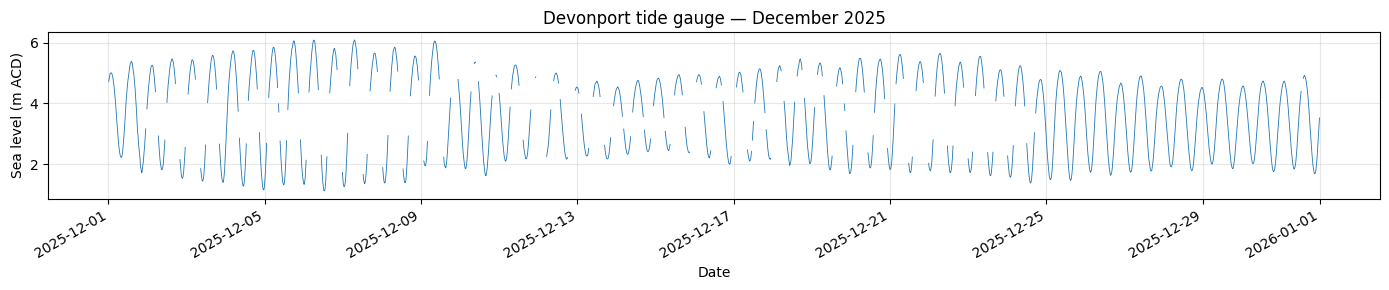

In [3]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(dates, elevations, lw=0.6, color='C0', label='Observed')
ax.set_ylabel('Sea level (m ACD)')
ax.set_xlabel('Date')
ax.set_title('Devonport tide gauge — December 2025')
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 2. Harmonic analysis with UTide

`analyse_harmonics` is a thin wrapper around `utide.solve` that:

- accepts a batch of positions simultaneously (`elevations` is `(npositions, ntimes)`);
- re-sorts UTide's output to match the requested constituent order;
- skips positions with `NaN` latitudes (useful for MPI padding; not relevant here).

For a single gauge we pass `elevations` as shape `(1, ntimes)` and
`latitudes` as `[GAUGE_LAT]`.

The time series is first demeaned so that the harmonic amplitudes represent
the tidal signal rather than the offset above chart datum.

In [4]:
# Demean: harmonics describe variation, not absolute offset
mean_elev    = np.nanmean(elevations)
elev_anomaly = elevations - mean_elev

# Convert datetimes to Modified Julian Days (what UTide expects)
times_mjd = date2num(dates, units=f'days since {MJD_ZERO_POINT} 00:00:00')

harmonics, predicted = analyse_harmonics(
    times     = times_mjd,
    elevations= elev_anomaly.reshape(1, -1),
    latitudes = np.array([GAUGE_LAT]),
    predict   = True,
    constit   = DEFAULT_CONSTIT,
    verbose   = False,
)

# Unpack: harmonics shape is (1, 2, nconsts)
# axis 1, index 0 = phase (degrees); index 1 = amplitude (m)
gauge_phase     = harmonics[0, 0, :]   # degrees
gauge_amplitude = harmonics[0, 1, :]   # metres
reconstructed   = predicted[0, :]      # metres

print(f"{'Constituent':>12}  {'Amplitude (m)':>14}  {'Phase (deg)':>10}")
print('-' * 42)
for name, amp, phase in zip(DEFAULT_CONSTIT, gauge_amplitude, gauge_phase):
    print(f'{name:>12}  {amp:>14.4f}  {phase:>10.2f}')

 Constituent   Amplitude (m)  Phase (deg)
------------------------------------------
          M2          1.6926      151.15
          S2          0.6658      189.80
          N2          0.3401      119.71
          K2          0.2051      165.23
          K1          0.0857      124.33
          O1          0.0579      340.30
          P1          0.0134       57.87
          Q1          0.0169      294.61
          M4          0.1122      119.75
         MS4          0.0379      170.69
         MN4          0.0624       94.59


## 3. TPXO10 harmonics at the gauge location

We use the same TPXO reader used elsewhere in pyfvcom2 to extract elevation
harmonics at the Devonport position.  A small bounding box around the gauge
reduces memory usage when loading the global TPXO grid.

In [5]:
# Build the per-constituent file dictionary
tpxo_h_files = {
    c: f'{TPXO_DIR}/h_{c.lower()}_tpxo10_atlas_30_v2.nc'
    for c in DEFAULT_CONSTIT
}

# Bounding box: 1° margin around the gauge
margin = 1.0
bbox = (GAUGE_LON - margin, GAUGE_LON + margin,
        GAUGE_LAT - margin, GAUGE_LAT + margin)

h_reader    = TPXOComplexHarmonicsReader(tpxo_h_files)
h_var_names = get_tpxo_complex_harmonics_names('zeta')
h_harmonics = h_reader.read_harmonics(
    list(DEFAULT_CONSTIT), h_var_names,
    fill_land=True, bbox=bbox, bbox_margin=0.1,
)

# Interpolate to the single gauge point
interp_coords = InterpolationCoordinates(
    dates=None, x3=None,
    x1=np.array([GAUGE_LON]),
    x2=np.array([GAUGE_LAT]),
    horizontal_coordinate_system='geographic',
    vertical_coordinate_system='z',
)
h_result = TPXOInterpolator(h_harmonics).interpolate(interp_coords)

# h_result.amplitudes shape: (n_points, n_constituents) → take index 0
tpxo_amplitude = np.asarray(h_result.amplitudes)[0, :]   # metres
tpxo_phase     = np.asarray(h_result.phases)[0, :]       # degrees

# Normalise TPXO phases to [0°, 360°) to match the UTide convention
tpxo_phase = tpxo_phase % 360

print(f"{'Constituent':>12}  {'TPXO amp (m)':>13}  {'TPXO phase (deg)':>14}")
print('-' * 44)
for name, amp, phase in zip(DEFAULT_CONSTIT, tpxo_amplitude, tpxo_phase):
    print(f'{name:>12}  {amp:>13.4f}  {phase:>14.2f}')

 Constituent   TPXO amp (m)  TPXO phase (deg)
--------------------------------------------
          M2         1.6833          154.08
          S2         0.5968          205.42
          N2         0.3074          137.91
          K2         0.1703          202.82
          K1         0.0788          113.96
          O1         0.0553          347.47
          P1         0.0253          108.43
          Q1         0.0148          298.30
          M4         0.1531          131.60
         MS4         0.1001          181.75
         MN4         0.0557           98.86


## 4. Comparison: UTide vs TPXO

Bar charts of amplitude and phase for each constituent.

A few things to keep in mind when interpreting the comparison:

- UTide amplitudes come from a one-month record; seasonal effects and surge
  can bias individual constituent estimates slightly.
- TPXO10 Atlas represents long-term tidal climatology — not December 2025
  specifically.
- Both phase sets use the **Greenwich phase-lag convention** and are
  normalised to **[0°, 360°)** for a consistent visual comparison.
- Small shallow-water constituents (M4, MS4, MN4) may not be well resolved
  by TPXO at the coarse 30 arc-minute resolution.

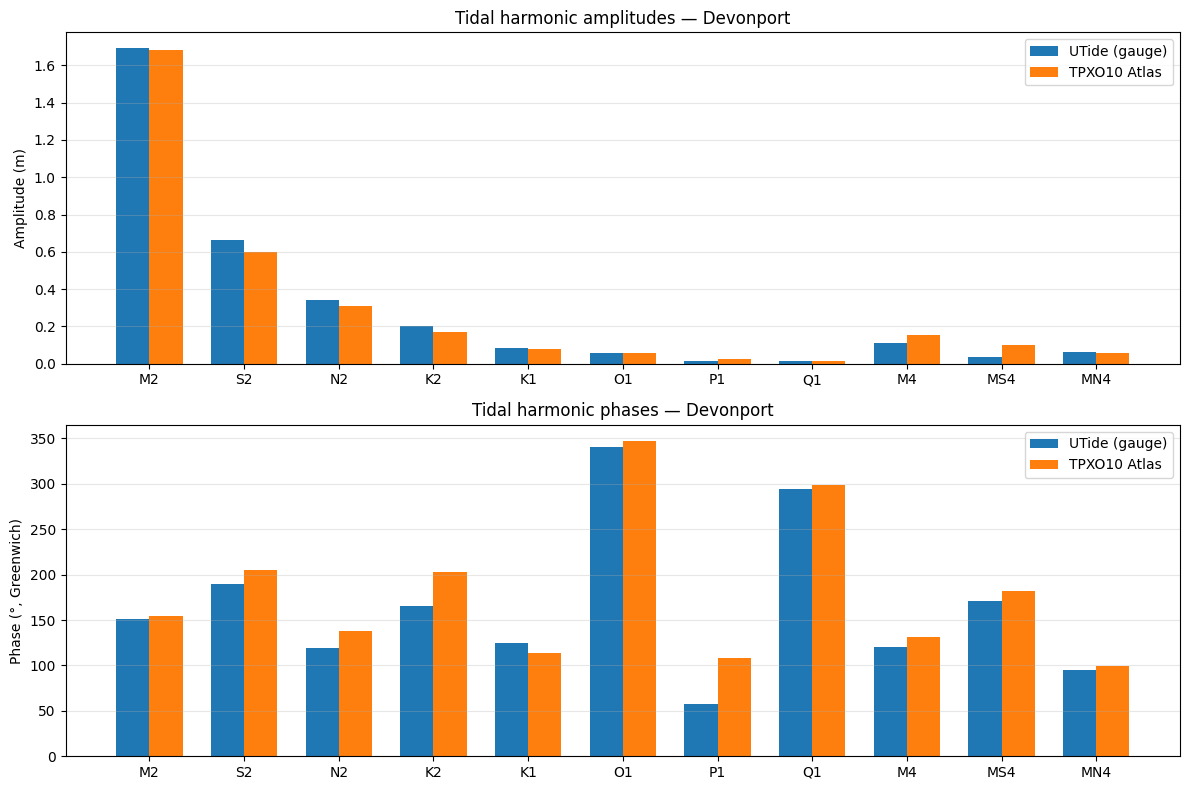

In [6]:
constit_labels = list(DEFAULT_CONSTIT)
x = np.arange(len(constit_labels))
w = 0.35

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ── Amplitude ─────────────────────────────────────────────────────────────────
axes[0].bar(x - w/2, gauge_amplitude, w, label='UTide (gauge)', color='C0')
axes[0].bar(x + w/2, tpxo_amplitude,  w, label='TPXO10 Atlas', color='C1')
axes[0].set_xticks(x)
axes[0].set_xticklabels(constit_labels)
axes[0].set_ylabel('Amplitude (m)')
axes[0].set_title('Tidal harmonic amplitudes — Devonport')
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)

# ── Phase ─────────────────────────────────────────────────────────────────────
axes[1].bar(x - w/2, gauge_phase, w, label='UTide (gauge)', color='C0')
axes[1].bar(x + w/2, tpxo_phase,  w, label='TPXO10 Atlas', color='C1')
axes[1].set_xticks(x)
axes[1].set_xticklabels(constit_labels)
axes[1].set_ylabel('Phase (°, Greenwich)')
axes[1].set_title('Tidal harmonic phases — Devonport')
axes[1].legend()
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Reconstructed tide vs observations

UTide's `predict=True` flag returned a time series reconstructed from the
fitted harmonics.  Overlaying it on the raw observations shows how well the
harmonic model captures the observed signal, and makes the residual (surge +
model error) visible.

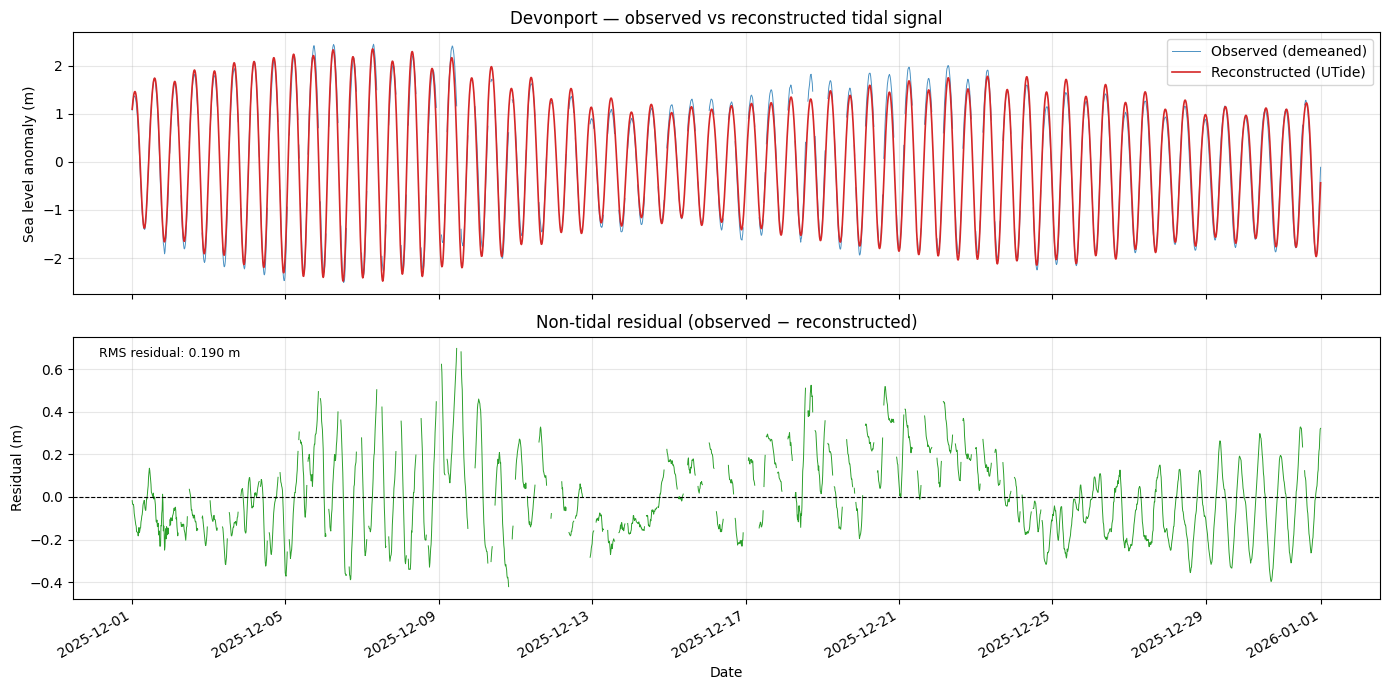

In [7]:
residual = elev_anomaly - reconstructed   # non-tidal residual

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Panel 1: observed anomaly with reconstructed tide
axes[0].plot(dates, elev_anomaly,  lw=0.7, color='C0', alpha=0.8, label='Observed (demeaned)')
axes[0].plot(dates, reconstructed, lw=1.2, color='C3', label='Reconstructed (UTide)')
axes[0].set_ylabel('Sea level anomaly (m)')
axes[0].set_title('Devonport — observed vs reconstructed tidal signal')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: non-tidal residual
axes[1].plot(dates, residual, lw=0.7, color='C2')
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_ylabel('Residual (m)')
axes[1].set_xlabel('Date')
axes[1].set_title('Non-tidal residual (observed − reconstructed)')
axes[1].grid(True, alpha=0.3)

rms = np.sqrt(np.nanmean(residual**2))
axes[1].text(0.02, 0.92, f'RMS residual: {rms:.3f} m',
             transform=axes[1].transAxes, fontsize=9)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()